# Alignment improvement grouped by first-order spectral variance

We cross the two ingredients the query describes:

1. **Spectral grouping** (from `spex_scaling-Landon-edits.ipynb`). For every test protein we take the SPEX Fourier spectrum and compute the proportion of spectral variance carried by **first-order (order-1) interactions** (order-0 / mean term excluded, orders > 4 lumped into 4, exactly as the notebook does). We do this twice: once with the `f_max` value function (SPEX runs with `rmax=True`) and once with `f_avg` (`rmax=False`). A protein is placed in the **`>50%`** group if its order-1 variance share exceeds 50% (first-order dominated), otherwise **`<=50%`**.
   - Each protein has a single `f_max` SPEX run but several `f_avg` runs, so the `f_avg` representative is the **mean** order-1 share across that protein's available runs.

2. **Alignment improvement** (from `eval_results/single_step_comps_test`). Four experiments: LASSO and Spectral Feedback, each with `rmax=True` (→ `f_max`) and `rmax=False` (→ `f_avg`). For each protein we take its **first trajectory** in the CSV and read the `spec_trajectory` reward before (`[0]`) and after (`[-1]`) the feedback step. Alignment improvement = `end - start` (we also report the % improvement).

Combining these gives **8 groups**: {`f_avg`, `f_max`} × {LASSO, Spectral Feedback} × {`>50%`, `<=50%`}, and we report the average alignment improvement in each.

In [1]:
import ast
import os
import pickle
from collections import defaultdict

import numpy as np
import pandas as pd

SPEX_DIR = "eval_results/spex_logs/r2_data_test"
CSV_DIR = "eval_results/single_step_comps_test"
MAX_ORDER = 4  # orders > MAX_ORDER are lumped into MAX_ORDER (matches spex_scaling notebook)

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 1. Spectral grouping: first-order variance share per protein (f_avg and f_max)

In [2]:
def build_rmax_map(spex_dir):
    """Map SPEX timestamp -> (rmax, beta) using the heldout_masks filenames."""
    m = {}
    for f in os.listdir(spex_dir):
        if f.startswith("heldout_masks"):
            rmax = f[f.index("max=") + 4:].split("_", 1)[0] == "True"
            beta, tail = f[f.index("beta=") + 5:].split("_", 1)
            m[tail[:-len(".txt")]] = (rmax, beta)
    return m


def order1_variance_pct(fourier_dict):
    """Proportion (%) of spectral variance in first-order interactions.

    Order-0 (mean) term is excluded and orders > MAX_ORDER are folded into
    MAX_ORDER, mirroring the variance decomposition in spex_scaling-Landon-edits.ipynb.
    """
    energy = {}
    for freq, coef in fourier_dict.items():
        order = min(int(sum(freq)), MAX_ORDER)
        if order == 0:
            continue
        energy[order] = energy.get(order, 0.0) + float(coef) ** 2
    total = sum(energy.values())
    if total <= 0:
        return np.nan
    return 100.0 * energy.get(1, 0.0) / total


rmax_map = build_rmax_map(SPEX_DIR)

# order1_runs[protein][variant] = list of order-1 variance shares (one per SPEX run)
order1_runs = defaultdict(lambda: defaultdict(list))
for f in os.listdir(SPEX_DIR):
    if f.startswith("fourier_dict__") and f.endswith(".pkl"):
        base = f[len("fourier_dict__"):-len(".pkl")]
        last = len(base) - base[::-1].index("_") - 1
        name, ts = base[:last], base[last + 1:]
        if ts not in rmax_map:
            continue
        rmax, _ = rmax_map[ts]
        fdict = pickle.load(open(os.path.join(SPEX_DIR, f), "rb"))
        variant = "f_max" if rmax else "f_avg"
        order1_runs[name][variant].append(order1_variance_pct(fdict))

# Representative order-1 share per (protein, variant) = mean over that variant's runs.
spec_order1 = {}
for name, variants in order1_runs.items():
    for variant, vals in variants.items():
        vals = [v for v in vals if not np.isnan(v)]
        if vals:
            spec_order1[(name, variant)] = float(np.mean(vals))


def spec_group(name, variant):
    """'>50%' if first-order variance share exceeds 50%, else '<=50%'."""
    p = spec_order1.get((name, variant))
    if p is None:
        return None
    return ">50%" if p > 50.0 else "<=50%"


grouping = pd.DataFrame(
    [
        {
            "protein": name,
            "variant": variant,
            "n_spex_runs": len(order1_runs[name][variant]),
            "order1_variance_%": spec_order1[(name, variant)],
            "group": spec_group(name, variant),
        }
        for (name, variant) in sorted(spec_order1)
    ]
)
grouping

,protein,variant,n_spex_runs,order1_variance_%,group
0,1F0M,f_avg,8,66.1888,>50%
1,1F0M,f_max,1,64.6209,>50%
2,2KRU,f_avg,5,52.0687,>50%
3,2KRU,f_max,1,75.0333,>50%
4,2L09,f_avg,5,44.3325,<=50%
5,2L09,f_max,1,66.9720,>50%
6,2LVN,f_avg,2,56.4055,>50%
7,2LVN,f_max,1,53.5214,>50%
8,2M2J,f_avg,9,67.8239,>50%
9,2M2J,f_max,1,71.2455,>50%


## 2. First-trajectory alignment improvement per protein, per experiment

In [3]:
# f_max <-> rmax=True CSVs, f_avg <-> rmax=False CSVs.
CSV_FILES = {
    ("f_avg", "LASSO"): "pretrained_test_ddg_bon_N=1_feedbacksteps=1_feedbackmethod=lasso_maxspecorder=20_masks=8192_rmax=False_lassolambda=0.0001_tilt_beta=1.0.csv",
    ("f_avg", "Spectral Feedback"): "pretrained_test_ddg_bon_N=1_feedbacksteps=1_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=False__tilt_beta=1.0.csv",
    ("f_max", "LASSO"): "pretrained_test_ddg_bon_N=10_feedbacksteps=1_feedbackmethod=lasso_maxspecorder=20_masks=8192_rmax=True_lassolambda=0.0001_tilt_beta=1.0.csv",
    ("f_max", "Spectral Feedback"): "pretrained_test_ddg_bon_N=10_feedbacksteps=1_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=True__tilt_beta=1.0.csv",
}


def first_trajectory_per_protein(path):
    """One row per protein (its first trajectory), with the spec_trajectory delta."""
    df = pd.read_csv(path)
    df = df.drop_duplicates("protein_name", keep="first").copy()
    df["protein"] = df["protein_name"].str.replace(r"\.pdb$", "", regex=True)
    traj = df["spec_trajectory"].apply(ast.literal_eval)
    df["start"] = traj.apply(lambda t: float(t[0]))
    df["end"] = traj.apply(lambda t: float(t[-1]))
    df["improvement"] = df["end"] - df["start"]
    df["pct_improvement"] = df["improvement"] / df["start"].abs() * 100.0
    return df[["protein", "start", "end", "improvement", "pct_improvement"]]


records = []
for (variant, method), fname in CSV_FILES.items():
    traj = first_trajectory_per_protein(os.path.join(CSV_DIR, fname))
    for _, row in traj.iterrows():
        records.append(
            {
                "variant": variant,
                "method": method,
                "protein": row["protein"],
                "group": spec_group(row["protein"], variant),
                "start": row["start"],
                "end": row["end"],
                "improvement": row["improvement"],
                "pct_improvement": row["pct_improvement"],
            }
        )

traj_df = pd.DataFrame(records)
traj_df

,variant,method,protein,group,start,end,improvement,pct_improvement
0,f_avg,LASSO,r6_560_TrROS_Hall,>50%,0.0679,0.4199,0.3521,518.8010
1,f_avg,LASSO,HEEH_KT_rd6_0746,>50%,-0.1234,0.3942,0.5176,419.3017
2,f_avg,LASSO,2LVN,>50%,0.0004,0.0309,0.0305,7026.4548
3,f_avg,LASSO,v2K43S_2KVV,>50%,-0.1766,0.2526,0.4291,243.0229
4,f_avg,LASSO,2M2J,>50%,0.3021,0.5536,0.2515,83.2491
5,f_avg,LASSO,2MA4,<=50%,-0.0216,0.2575,0.2792,1291.6951
6,f_avg,LASSO,1F0M,>50%,0.6251,0.7427,0.1175,18.8013
7,f_avg,LASSO,5JRT,<=50%,0.3523,0.4047,0.0524,14.8719
8,f_avg,LASSO,7JJK,>50%,0.6095,0.6803,0.0708,11.6143
9,f_avg,LASSO,2KRU,>50%,0.4353,0.5789,0.1436,32.9934


## 3. Average alignment improvement in each of the 8 groups

In [4]:
summary = (
    traj_df.groupby(["variant", "method", "group"])
    .agg(
        n_proteins=("protein", "nunique"),
        mean_improvement=("improvement", "mean"),
        mean_pct_improvement=("pct_improvement", "mean"),
    )
    .reset_index()
    .sort_values(["variant", "method", "group"])
    .reset_index(drop=True)
)
summary

,variant,method,group,n_proteins,mean_improvement,mean_pct_improvement
0,f_avg,LASSO,<=50%,3,0.1995,509.9746
1,f_avg,LASSO,>50%,9,0.2175,929.6953
2,f_avg,Spectral Feedback,<=50%,3,0.2529,772.4663
3,f_avg,Spectral Feedback,>50%,9,0.2475,950.1318
4,f_max,LASSO,<=50%,2,0.1199,41.4877
5,f_max,LASSO,>50%,10,0.1554,47.5936
6,f_max,Spectral Feedback,<=50%,2,0.1477,52.1553
7,f_max,Spectral Feedback,>50%,10,0.1754,53.4085


In [5]:
for (variant, method), block in summary.groupby(["variant", "method"]):
    print(f"=== {variant} + {method} ===")
    for _, r in block.iterrows():
        members = sorted(
            traj_df[(traj_df.variant == variant) & (traj_df.method == method) & (traj_df.group == r['group'])]["protein"]
        )
        print(
            f"  first-order variance {r['group']:>5s} "
            f"({int(r['n_proteins'])} proteins): "
            f"mean improvement {r['mean_improvement']:+.4f}  "
            f"(mean {r['mean_pct_improvement']:+.1f}%)"
        )
        print(f"      proteins: {', '.join(members)}")
    print()

=== f_avg + LASSO ===
  first-order variance <=50% (3 proteins): mean improvement +0.1995  (mean +510.0%)
      proteins: 2L09, 2MA4, 5JRT
  first-order variance  >50% (9 proteins): mean improvement +0.2175  (mean +929.7%)
      proteins: 1F0M, 2KRU, 2LVN, 2M2J, 4G3O, 7JJK, HEEH_KT_rd6_0746, r6_560_TrROS_Hall, v2K43S_2KVV

=== f_avg + Spectral Feedback ===
  first-order variance <=50% (3 proteins): mean improvement +0.2529  (mean +772.5%)
      proteins: 2L09, 2MA4, 5JRT
  first-order variance  >50% (9 proteins): mean improvement +0.2475  (mean +950.1%)
      proteins: 1F0M, 2KRU, 2LVN, 2M2J, 4G3O, 7JJK, HEEH_KT_rd6_0746, r6_560_TrROS_Hall, v2K43S_2KVV

=== f_max + LASSO ===
  first-order variance <=50% (2 proteins): mean improvement +0.1199  (mean +41.5%)
      proteins: 2MA4, 7JJK
  first-order variance  >50% (10 proteins): mean improvement +0.1554  (mean +47.6%)
      proteins: 1F0M, 2KRU, 2L09, 2LVN, 2M2J, 4G3O, 5JRT, HEEH_KT_rd6_0746, r6_560_TrROS_Hall, v2K43S_2KVV

=== f_max + Sp

## 4. Tradeoff: mean improvement of the `<=k%` group vs. the threshold k%

The 50% cutoff above is one point on a continuum. Here we sweep the threshold `k` over the
full range of first-order variance shares and follow only the **`<=k%`** group (proteins whose
first-order variance share is at most `k`). We plot that group's **mean alignment improvement**
as a function of `k`, comparing **LASSO vs. Spectral Feedback** in one panel for `f_avg` and one
panel for `f_max`. The dashed line marks `k = 50%`; point labels show the group size at a few
reference thresholds.

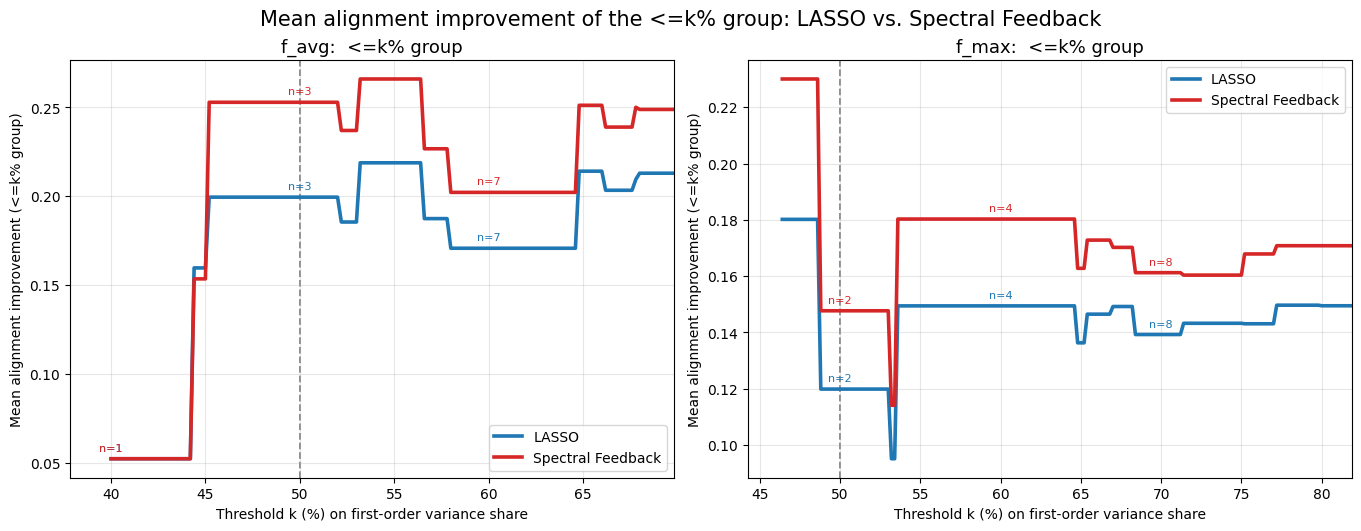

saved: /u/sdickman/DRAKES/drakes_protein/fmif/neurips_rebut3_tradeoff.png


In [6]:
import matplotlib.pyplot as plt

# First-order variance share for each trajectory (depends only on protein + variant).
traj_df["order1_variance_%"] = [
    spec_order1.get((p, v)) for p, v in zip(traj_df["protein"], traj_df["variant"])
]

METHOD_COLORS = {"LASSO": "#1f77b4", "Spectral Feedback": "#d62728"}
ks = np.linspace(0.0, 100.0, 501)


def below_curve(variant, method):
    """Mean improvement and size of the <=k% group across the k sweep."""
    sub = traj_df[(traj_df.variant == variant) & (traj_df.method == method)]
    o1 = sub["order1_variance_%"].to_numpy(dtype=float)
    imp = sub["improvement"].to_numpy(dtype=float)
    means, counts = [], []
    for k in ks:
        bm = imp[o1 <= k]
        means.append(bm.mean() if len(bm) else np.nan)
        counts.append(len(bm))
    return np.array(means), counts, o1


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)
for ax, variant in zip(axes, ["f_avg", "f_max"]):
    o1_ref = None
    for method, color in METHOD_COLORS.items():
        means, counts, o1 = below_curve(variant, method)
        o1_ref = o1
        ax.plot(ks, means, color=color, lw=2.6, label=method)
        for kref in (40, 50, 60, 70):
            idx = int(np.argmin(np.abs(ks - kref)))
            if not np.isnan(means[idx]):
                ax.annotate(f"n={counts[idx]}", (kref, means[idx]), color=color,
                            fontsize=8, ha="center", va="bottom", xytext=(0, 4),
                            textcoords="offset points")
    ax.axvline(50.0, color="0.4", ls="--", lw=1.3, alpha=0.8, zorder=1)
    lo, hi = np.nanmin(o1_ref), np.nanmax(o1_ref)
    ax.set_xlim(lo - 2, hi + 2)
    ax.set_title(f"{variant}:  <=k% group", fontsize=13)
    ax.set_xlabel("Threshold k (%) on first-order variance share")
    ax.set_ylabel("Mean alignment improvement (<=k% group)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="best")
 
fig.suptitle("Mean alignment improvement of the <=k% group: LASSO vs. Spectral Feedback",
             fontsize=15)
out_png = "neurips_rebut3_tradeoff.png"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", os.path.abspath(out_png))

## 5. Same tradeoff for the `>k%` group

The mirror image of the previous plot: we now follow the **`>k%`** group (proteins whose
first-order variance share exceeds `k`, i.e. the first-order dominated ones) and compare
**LASSO vs. Spectral Feedback** for `f_avg` and `f_max`. Same k sweep, same `k = 50%` marker
and group-size labels.

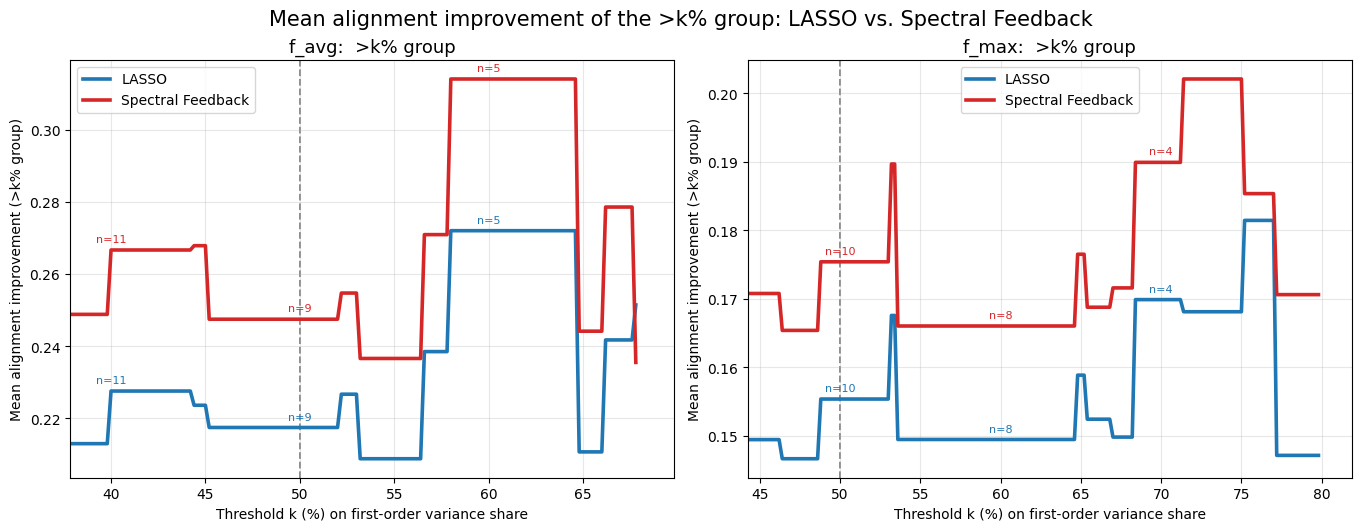

saved: /u/sdickman/DRAKES/drakes_protein/fmif/neurips_rebut3_tradeoff_above.png


In [18]:
def above_curve(variant, method):
    """Mean improvement and size of the >k% group across the k sweep."""
    sub = traj_df[(traj_df.variant == variant) & (traj_df.method == method)]
    o1 = sub["order1_variance_%"].to_numpy(dtype=float)
    imp = sub["improvement"].to_numpy(dtype=float)
    means, counts = [], []
    for k in ks:
        am = imp[o1 > k]
        means.append(am.mean() if len(am) else np.nan)
        counts.append(len(am))
    return np.array(means), counts, o1


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)
for ax, variant in zip(axes, ["f_avg", "f_max"]):
    o1_ref = None
    for method, color in METHOD_COLORS.items():
        means, counts, o1 = above_curve(variant, method)
        o1_ref = o1
        ax.plot(ks, means, color=color, lw=2.6, label=method)
        for kref in (40, 50, 60, 70):
            idx = int(np.argmin(np.abs(ks - kref)))
            if not np.isnan(means[idx]):
                ax.annotate(f"n={counts[idx]}", (kref, means[idx]), color=color,
                            fontsize=8, ha="center", va="bottom", xytext=(0, 4),
                            textcoords="offset points")
    ax.axvline(50.0, color="0.4", ls="--", lw=1.3, alpha=0.8, zorder=1)
    lo, hi = np.nanmin(o1_ref), np.nanmax(o1_ref)
    ax.set_xlim(lo - 2, hi + 2)
    ax.set_title(f"{variant}:  >k% group", fontsize=13)
    ax.set_xlabel("Threshold k (%) on first-order variance share")
    ax.set_ylabel("Mean alignment improvement (>k% group)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="best")

fig.suptitle("Mean alignment improvement of the >k% group: LASSO vs. Spectral Feedback",
             fontsize=15)
out_png_above = "neurips_rebut3_tradeoff_above.png"
fig.savefig(out_png_above, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", os.path.abspath(out_png_above))